**Trader Performance vs Market Sentiment Analysis**

This analysis explores how market sentiment (Fear vs Greed) influences trader behavior and 
  performance using Hyperliquid trading data and Bitcoin Fear & Greed Index.

The objective is to identify behavioral patterns and derive actionable trading insights.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Part A: Data Preparation**

*Step 1: Load datasets*

In [4]:
sentiment = pd.read_csv("fear_greed_index.csv")

In [5]:
Trades = pd.read_csv("historical_data.csv")

In [6]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [7]:
Trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


Step 2: Dataset overview
- Checking number of rows and columns
- Inspecting column names
- Checking missing values and duplicates

In [8]:
sentiment.shape

(2644, 4)

In [9]:
Trades.shape

(211224, 16)

The sentiment dataset contains 2,644 rows and 4 columns.

The historical trading dataset contains 211,224 rows and 17 columns, representing individual trade records.

In [10]:
sentiment.columns

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')

In [11]:
Trades.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')

In [12]:
sentiment.info

<bound method DataFrame.info of        timestamp  value classification        date
0     1517463000     30           Fear  2018-02-01
1     1517549400     15   Extreme Fear  2018-02-02
2     1517635800     40           Fear  2018-02-03
3     1517722200     24   Extreme Fear  2018-02-04
4     1517808600     11   Extreme Fear  2018-02-05
...          ...    ...            ...         ...
2639  1745818200     54        Neutral  2025-04-28
2640  1745904600     60          Greed  2025-04-29
2641  1745991000     56          Greed  2025-04-30
2642  1746077400     53        Neutral  2025-05-01
2643  1746163800     67          Greed  2025-05-02

[2644 rows x 4 columns]>

In [13]:
Trades.info

<bound method DataFrame.info of                                            Account      Coin  Execution Price  \
0       0xae5eacaf9c6b9111fd53034a602c192a04e082ed      @107           7.9769   
1       0xae5eacaf9c6b9111fd53034a602c192a04e082ed      @107           7.9800   
2       0xae5eacaf9c6b9111fd53034a602c192a04e082ed      @107           7.9855   
3       0xae5eacaf9c6b9111fd53034a602c192a04e082ed      @107           7.9874   
4       0xae5eacaf9c6b9111fd53034a602c192a04e082ed      @107           7.9894   
...                                            ...       ...              ...   
211219  0x72743ae2822edd658c0c50608fd7c5c501b2afbd  FARTCOIN           1.1010   
211220  0x72743ae2822edd658c0c50608fd7c5c501b2afbd  FARTCOIN           1.1010   
211221  0x72743ae2822edd658c0c50608fd7c5c501b2afbd  FARTCOIN           1.1010   
211222  0x72743ae2822edd658c0c50608fd7c5c501b2afbd  FARTCOIN           1.1010   
211223  0x72743ae2822edd658c0c50608fd7c5c501b2afbd  FARTCOIN           1.1010

In [14]:
sentiment.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [15]:
Trades.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [16]:
Trades.isnull().sum().sum()

0

In [17]:
sentiment.isnull().sum().sum()

0

In [18]:
sentiment.duplicated().sum()

0

In [19]:
Trades.duplicated().sum()

0

No missing values were detected in the sentiment dataset.

The trading dataset was also checked for missing values and duplicates. No duplicate records were found, ensuring data integrity for analysis.

Step 3: Timestamp Conversion



In [20]:
sentiment['date'].dtype

dtype('O')

In [21]:
Trades['Timestamp IST'].dtype

dtype('O')

In [22]:
Trades['Timestamp'].dtype

dtype('float64')

In [23]:
sentiment['date'] = pd.to_datetime(sentiment['date'])

In [24]:
Trades['Timestamp'] = pd.to_datetime(Trades['Timestamp'])

In [25]:
Trades['Timestamp IST'] = pd.to_datetime(Trades['Timestamp IST'], dayfirst = True)

In [26]:
Trades['Timestamp IST'].dtype

dtype('<M8[ns]')

In [27]:
Trades['date'] = Trades['Timestamp IST'].dt.date

In [28]:
sentiment['date'].head()

0   2018-02-01
1   2018-02-02
2   2018-02-03
3   2018-02-04
4   2018-02-05
Name: date, dtype: datetime64[ns]

In [29]:
Trades['date'] = Trades['Timestamp IST'].dt.normalize()

In [30]:
Trades['date'].dtype

dtype('<M8[ns]')

In [31]:
Trades['date'].head()

0   2024-12-02
1   2024-12-02
2   2024-12-02
3   2024-12-02
4   2024-12-02
Name: date, dtype: datetime64[ns]

The sentiment dataset contains a date column representing daily sentiment classification.

The trading dataset includes timestamps for each trade. These timestamps were converted to datetime format 
 and normalized to daily granularity so both datasets could be aligned by date.

*Step 4: Dataset Alignment*



In [38]:
merged_data = Trades.merge(sentiment, on = 'date', how = 'left')

In [39]:
merged_data.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1970-01-01 00:28:50,2024-12-02,1.733117e+09,80.0,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1970-01-01 00:28:50,2024-12-02,1.733117e+09,80.0,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1970-01-01 00:28:50,2024-12-02,1.733117e+09,80.0,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1970-01-01 00:28:50,2024-12-02,1.733117e+09,80.0,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1970-01-01 00:28:50,2024-12-02,1.733117e+09,80.0,Extreme Greed


In [40]:
merged_data.shape

(211224, 20)

*The two datasets were merged on the `date` column using a left join so that 
  each trade record is associated with the corresponding market sentiment for that day.*

**Metric Creation**

To analyze trader behavior and performance, several metrics were created:

• Daily PnL per trader  
• Win rate per trader  
• Average trade size  
• Number of trades per day  
• Long vs Short ratio


In [41]:
#Daily PnL per Trader/Account

In [42]:
daily_pnl = merged_data.groupby(['Account','date'])['Closed PnL'].sum().reset_index()

In [43]:
daily_pnl.head()

,Account,date,Closed PnL
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.0
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.0
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.0
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.0
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.1


*Daily PnL per trader was calculated by summing all closed PnL values for each account on each trading day.*

In [44]:
#Win Rate

In [45]:
merged_data['Win'] = merged_data['Closed PnL'] > 0

In [46]:
merged_data['Win'].head(50)

0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11    False
12    False
13    False
14    False
15    False
16    False
17    False
18    False
19    False
20    False
21    False
22    False
23    False
24    False
25    False
26    False
27    False
28    False
29    False
30    False
31    False
32    False
33    False
34    False
35    False
36    False
37    False
38    False
39    False
40    False
41    False
42    False
43    False
44     True
45     True
46     True
47     True
48     True
49     True
Name: Win, dtype: bool

In [47]:
Win_Rate = merged_data.groupby('Account')['Win'].mean()

In [48]:
win_Rate_Percent = Win_Rate*100

In [49]:
win_Rate_Percent.round(2)

Account
0x083384f897ee0f19899168e3b1bec365f52a9012    35.96
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd    44.27
0x271b280974205ca63b716753467d5a371de622ab    30.19
0x28736f43f1e871e6aa8b1148d38d4994275d72c4    43.86
0x2c229d22b100a7beb69122eed721cee9b24011dd    51.99
0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891    45.52
0x39cef799f8b69da1995852eea189df24eb5cae3c    32.77
0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6    47.59
0x420ab45e0bd8863569a5efbb9c05d91f40624641    23.50
0x430f09841d65beb3f27765503d0f850b8bce7713    48.42
0x47add9a56df66b524d5e2c1993a43cde53b6ed85    35.34
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    48.62
0x4f93fead39b70a1824f981a54d4e55b278e9f760    36.04
0x513b8629fe877bb581bf244e326a047b249c4ff1    40.12
0x6d6a4b953f202f8df5bed40692e7fd865318264a    43.18
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    34.59
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    30.63
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    81.09
0x7f4f299f74eec87806a830e3caa9afa5f2b9db8f    45.22
0x81

*Win rate represents the percentage of profitable trades for each trader.
A trade is considered a win if Closed PnL > 0.*

In [50]:
#Average Trade Size

In [51]:
avg_trade_size = merged_data.groupby('Account')['Size USD'].mean()

In [52]:
avg_trade_size.head()

Account
0x083384f897ee0f19899168e3b1bec365f52a9012    16159.576734
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd     1653.226327
0x271b280974205ca63b716753467d5a371de622ab     8893.000898
0x28736f43f1e871e6aa8b1148d38d4994275d72c4      507.626933
0x2c229d22b100a7beb69122eed721cee9b24011dd     3138.894782
Name: Size USD, dtype: float64

*Average trade size measures the average position size (USD) used by each trader.*

In [53]:
#Number of Trades per day

In [54]:
trades_per_day = merged_data.groupby('date').size()

In [55]:
trades_per_day.head()

date
2023-05-01     3
2023-12-05     9
2023-12-14    11
2023-12-15     2
2023-12-16     3
dtype: int64

*Trading activity was measured by counting the number of trades executed each day.*

In [56]:
#Long/Short Ratio

In [57]:
Long_Short_Ratio = merged_data['Side'].value_counts(normalize= True)*100

In [58]:
Long_Short_Ratio.round(2)

Side
SELL    51.38
BUY     48.62
Name: proportion, dtype: float64

*The long/short ratio represents the percentage of BUY vs SELL trades in the dataset.*

**Part B Analysis**

This section analyzes how trader performance and behavior change across different market sentiment conditions (Fear vs Greed).

In [59]:
#Avg PnL during Fear VS Greed

In [60]:
pnl_by_sentiment = merged_data.groupby('classification')['Closed PnL'].mean()
pnl_by_sentiment

classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: Closed PnL, dtype: float64

*Extreme Fear has the lowest win rate (37%), suggesting high uncertainty reduces trading success.*

In [61]:
#WinRate during Fear VS Greed

In [62]:
winrate_by_sentiment = merged_data.groupby('classification')['Win'].mean() * 100
winrate_by_sentiment

classification
Extreme Fear     37.060748
Extreme Greed    46.494299
Fear             42.076750
Greed            38.482794
Neutral          39.699093
Name: Win, dtype: float64

*Traders achieve the highest win rate during Extreme Greed periods (46.5%), suggesting bullish markets provide clearer trading opportunities.*

In [63]:
#Avg Trade Size during Fear VS Greed

In [64]:
trade_size_sentiment = merged_data.groupby('classification')['Size USD'].mean()
trade_size_sentiment

classification
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: Size USD, dtype: float64

*Average trade size is largest during Fear periods (~$7816), indicating traders take larger positions during market uncertainty.*

In [65]:
trades_sentiment = merged_data.groupby('classification').size()
trades_sentiment

classification
Extreme Fear     21400
Extreme Greed    39992
Fear             61837
Greed            50303
Neutral          37686
dtype: int64

*Trading activity is highest during Fear, showing traders become more active when markets are volatile or falling.*

In [66]:
#Long vs Short Behavior

In [67]:
direction_sentiment = merged_data.groupby('classification')['Side'].value_counts(normalize=True) * 100
direction_sentiment

classification  Side
Extreme Fear    BUY     51.098131
                SELL    48.901869
Extreme Greed   SELL    55.141028
                BUY     44.858972
Fear            SELL    51.048725
                BUY     48.951275
Greed           SELL    51.144067
                BUY     48.855933
Neutral         BUY     50.334342
                SELL    49.665658
Name: proportion, dtype: float64

*During Extreme Fear, traders place slightly more BUY trades, indicating dip-buying.
During Extreme Greed, SELL trades increase, suggesting profit-taking.*

In [68]:
#Trade Size Behavior

In [69]:
trade_size_sentiment

classification
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: Size USD, dtype: float64

*Trade sizes are largest during Fear, meaning traders take bigger positions in volatile markets.
During Extreme Greed, trade sizes decrease, showing more cautious trading.*

In [70]:
#Frequent vs Infrequent Traders

In [71]:
trades_per_trader = merged_data.groupby('Account').size()
trades_per_trader

Account
0x083384f897ee0f19899168e3b1bec365f52a9012     3818
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd     7280
0x271b280974205ca63b716753467d5a371de622ab     3809
0x28736f43f1e871e6aa8b1148d38d4994275d72c4    13311
0x2c229d22b100a7beb69122eed721cee9b24011dd     3239
0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891      815
0x39cef799f8b69da1995852eea189df24eb5cae3c     3589
0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6      332
0x420ab45e0bd8863569a5efbb9c05d91f40624641      383
0x430f09841d65beb3f27765503d0f850b8bce7713     1237
0x47add9a56df66b524d5e2c1993a43cde53b6ed85     8519
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4     4356
0x4f93fead39b70a1824f981a54d4e55b278e9f760     7584
0x513b8629fe877bb581bf244e326a047b249c4ff1    12236
0x6d6a4b953f202f8df5bed40692e7fd865318264a      975
0x72743ae2822edd658c0c50608fd7c5c501b2afbd     1590
0x72c6a4624e1dffa724e6d00d64ceae698af892a0     1430
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4     9893
0x7f4f299f74eec87806a830e3caa9afa5f2b9db8f     1559
0x81

*Frequent traders actively trade the market, while infrequent traders participate less often.*

In [72]:
#Consistent vs Inconsistent Traders

In [73]:
pnl_std = merged_data.groupby('Account')['Closed PnL'].std()
pnl_std

Account
0x083384f897ee0f19899168e3b1bec365f52a9012    4692.452329
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd     134.073473
0x271b280974205ca63b716753467d5a371de622ab     542.182659
0x28736f43f1e871e6aa8b1148d38d4994275d72c4     113.269353
0x2c229d22b100a7beb69122eed721cee9b24011dd     255.829091
0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891     558.778753
0x39cef799f8b69da1995852eea189df24eb5cae3c     730.495484
0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6    1279.855788
0x420ab45e0bd8863569a5efbb9c05d91f40624641    2228.336140
0x430f09841d65beb3f27765503d0f850b8bce7713    1649.497580
0x47add9a56df66b524d5e2c1993a43cde53b6ed85      88.292842
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4     855.354003
0x4f93fead39b70a1824f981a54d4e55b278e9f760     656.693628
0x513b8629fe877bb581bf244e326a047b249c4ff1     639.402444
0x6d6a4b953f202f8df5bed40692e7fd865318264a     468.995982
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    2525.240437
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    1591.523958
0x75f7

*Consistent traders show stable performance, while inconsistent traders experience large profit and loss swings.*

*Create charts / tables for comparisons*

In [74]:
#PnL vs Sentiment

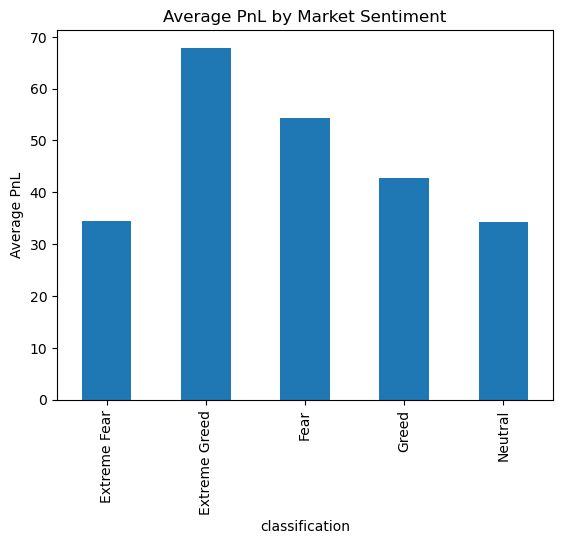

In [78]:
pnl_by_sentiment.plot(kind='bar')
plt.title("Average PnL by Market Sentiment")
plt.ylabel("Average PnL")
plt.savefig("avg_pnl_sentiment.png")
plt.show()

*Traders achieve the highest average PnL during Extreme Greed periods, suggesting bullish markets create more profitable trading opportunities.*

In [102]:
#Win Rate vs Sentiment

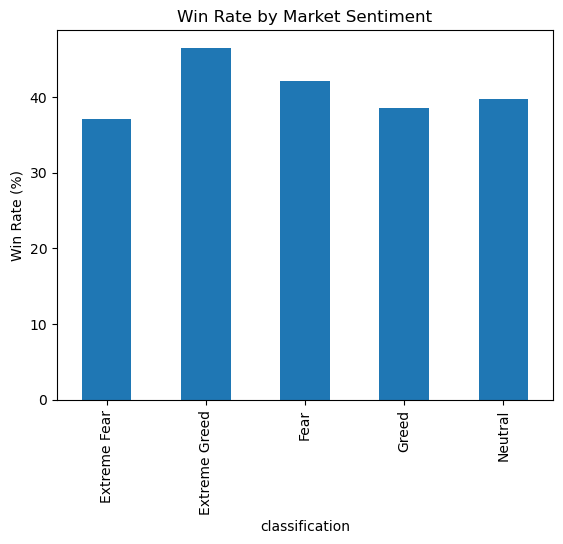

In [79]:
winrate_by_sentiment.plot(kind='bar')
plt.title("Win Rate by Market Sentiment")
plt.ylabel("Win Rate (%)")
plt.savefig("win_rate_sentiment.png")
plt.show()

*Traders increase position size during Fear and reduce it during Extreme Greed, indicating stronger conviction during falling markets*

In [106]:
#Trading Activity vs Sentiment

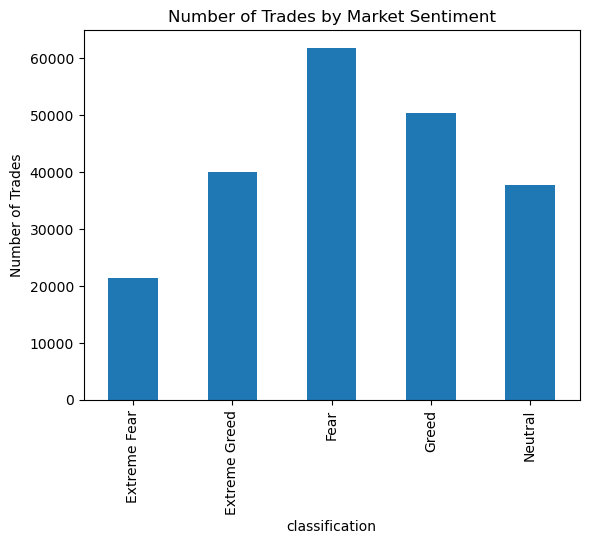

In [80]:
trades_sentiment.plot(kind='bar')
plt.title("Number of Trades by Market Sentiment")
plt.ylabel("Number of Trades")
plt.savefig("trade_activity_sentiment.png")
plt.show()

*Traders are most active when the market is fearful.*

**Part C: Strategies/Rules of Thumb**

*Strategy 1*

*During Fear markets, traders show higher trade size and trading activity.
Strategy: Increase position size moderately during Fear conditions, as traders tend to take larger positions 
and markets may present buying opportunities.*

*Strategy 2*

*During Extreme Greed, traders use smaller trade sizes and show moderate performance.
Strategy: Reduce position size during Extreme Greed, as markets may be overextended and risk of reversal increases.*